In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point, LineString
from opentnsim import graph

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr
from opentnsim.tidal_accessibility import HasDraughtRestrictions
from opentnsim.core import Identifiable, Movable 
from opentnsim.graph import HasMultiDiGraph
from opentnsim.core.vessel_properties import VesselProperties
from opentnsim.port.port import IsPort, HasPortAccess
from opentnsim.port.terminals import HasTerminal, IsTerminal, IsJetty, IsQuay
from opentnsim.port.anchorages import IsAnchorage, PassesAnchorage
from opentnsim.vessel_traffic_service import VesselTrafficService
from opentnsim import tidal_accessibility
from opentnsim.tidal_window_constructor import vessel_specifications, \
                                               vertical_tidal_window_specifications, \
                                               vertical_tidal_window_input, \
                                               horizontal_tidal_window_specifications, \
                                               horizontal_tidal_window_method, \
                                               horizontal_tidal_window_input, \
                                               tidal_period, \
                                               accessibility, \
                                               NetworkProperties
from opentnsim.rule_constructor import vessel_characteristics, vessel_direction, vessel_type

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np

# package(s) for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


In [2]:
%load_ext autoreload
%autoreload 2

#### Define input
graph

In [3]:
number_of_nodes = 11

vessel

In [4]:
vessel_length = 200
vessel_beam = 40
vessel_draught = 14.2
vessel_speed = 4.5 #m/s

# For capcity calculation (tonnes per year of TEU als alle soorten cargo worden meegenomen) realistic vessel properties should be used.
# Including the amount of cargo they can carry.
# For a more included capacity calcultion a fleet should be added instead of a single vessel. (use different vessel classes?, is er data ) 
# loading time 


infrastructure

In [5]:
waterway_length = 25000 #meters
waterway_depth = 15 #meters (NGD: nautical guaranteed depth = MBL: maintained bed level)

# Waterway_width needs to be added (this will provide 2 solutions; one-way or two-way channel.
# Possible bends in the waterway should also be included. (Maybe in the resulting extra draught that occurs in tight bends) 


# Natural depth, length and width should be added to calculate the impact. 
# breete kan 1 of 2 way berekening van pianc zijn (dus maar 2 opties( 

tide

In [6]:
tidal_period = 12.5 #hours
tidal_range_sea = 2.0 #meters
tidal_propagation_speed = np.sqrt(9.81*waterway_depth) #meters per second (np.sqrt(grav_acc*waterway_depth)), grav_acc=9.81
tidal_amplication = 0.8 #amplification factor

#can come from data as well? 

tidal restrictions

In [7]:
#percentage of the draught as UKC (10% of draught is common)
ukc_percentage = 10.0 * np.ones(number_of_nodes) #% of draught 

#static value as UKC (0.5 m is common, but not in combination with ukc_percentage)
ukc_static = 0.0 * np.ones(number_of_nodes) #meters

#freshwater allowance as percentage of draught as additional UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage common)
fwa = 0.0 * np.ones(number_of_nodes) #% of draught 

#### 0. Create environment

In [8]:
# set simulation time
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2024, 1, 8, 0, 0, 0)

# create time series aligned with simulation time
timestep = pd.Timedelta(minutes=5)
time_series = pd.date_range(simulation_start,simulation_stop,freq=timestep)

env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a single edge of 100 km exactly.

In [9]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [10]:
# starting point (longitude, latitude)
coordinates_sea = (0,0)

# compute the other point 100 km East from Point 0
coordinates_waterway = {}
coordinates_waterway[0] = coordinates_sea
coordinates_previous_node = coordinates_sea
for node in range(number_of_nodes-1):
    coordinates_node = geod.fwd(coordinates_previous_node[0], coordinates_previous_node[1], 90 ,waterway_length/(number_of_nodes-1)) #east from previous node
    coordinates_waterway[node+1] = (coordinates_node[0],coordinates_node[1])
    coordinates_previous_node = coordinates_node

In [11]:
# create list of edges
edges = []
for node_start,node_stop in zip(range(0,number_of_nodes-1),range(1,number_of_nodes)):
    edges.append((node_start,node_stop))
    edges.append((node_stop,node_start))

In [12]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for name, coordinate in coordinates_waterway.items():
    FG.add_node(name, geometry=Point(coordinate[0], coordinate[1]))

# add edges
for edge in edges:
    waterway_geometry = LineString([Point(coordinates_waterway[edge[0]]),Point(coordinates_waterway[edge[1]])])
    FG.add_edge(edge[0], edge[1], geometry=waterway_geometry, weight=1, length_m=waterway_length/(number_of_nodes-1))

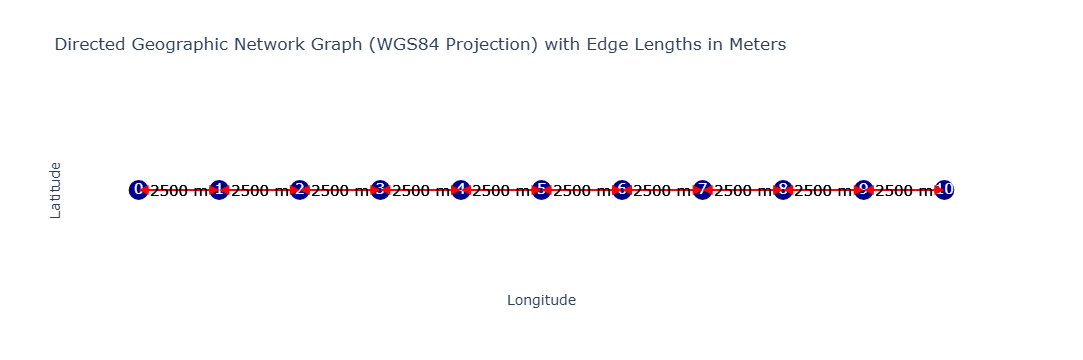

In [13]:
opentnsim.graph.plot_graph(FG)

In [14]:
# add graph to environment
env.graph = FG

In [15]:
# test multiple vessels 

# --- ADD: segment capacity (congestie) per edge ---
import simpy

def attach_edge_resources(env, FG, capacity_per_direction=1):
    """
    Zet op elke directed edge een SimPy Resource.
    capacity_per_direction=1 => max 1 schip tegelijk op dat segment per richting.
    """
    for u, v in FG.edges:
        FG.edges[u, v]["resource"] = simpy.Resource(env, capacity=capacity_per_direction)

attach_edge_resources(env, FG, capacity_per_direction=1)


#### 1a. Adding a Vessel Traffic Service (VTS)

In [16]:
# create empty hydrodynamic dataset
hydrodynamic_data = xr.Dataset()

In [17]:
water_level_data = np.zeros((number_of_nodes,len(time_series)))
for node in FG.nodes:
    route_to_sea = nx.dijkstra_path(FG,0,node)
    distance_to_sea = 0.
    for node_start,node_stop in zip(route_to_sea[:-1],route_to_sea[1:]):
        distance_to_sea += FG.edges[node_start,node_stop]['length_m']

    amplification_factor = 1 - 0.2*(distance_to_sea/waterway_length)
    phase_shift = pd.Timedelta(seconds=distance_to_sea/tidal_propagation_speed)
    tidal_amplitude = amplification_factor*(tidal_range_sea/2)
    tidal_water_level = tidal_amplitude*np.sin(2*np.pi*((time_series-simulation_start-phase_shift)/(12.5*pd.Timedelta(hours=1))))
    water_level_data[node] = tidal_water_level
water_level_data_array = xr.DataArray(data=water_level_data,coords={'STATION':FG.nodes,'TIME':time_series})

In [18]:
MBL_data = waterway_depth*np.ones([number_of_nodes,len(time_series)])
MBL_data_array = xr.DataArray(data=MBL_data,coords={'STATION':FG.nodes,'TIME':time_series})

In [19]:
hydrodynamic_data['Water level'] = water_level_data_array
hydrodynamic_data['MBL'] = MBL_data_array

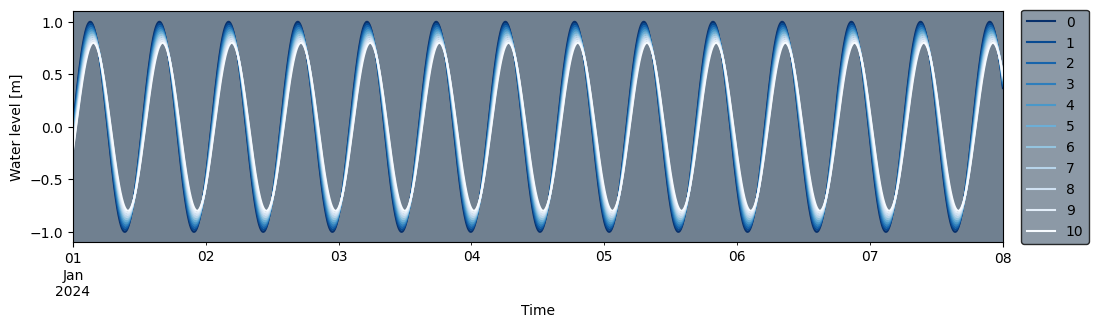

In [20]:
fig,ax = plt.subplots(figsize=[12,3])
ax.set_facecolor('slategray')
pd.DataFrame(hydrodynamic_data['Water level'].T,index=hydrodynamic_data['TIME']).plot(ax=ax,cmap='Blues_r')
ax.set_xlabel('Time')
ax.set_ylabel('Water level [m]')
ax.set_xlim(time_series[0],time_series[-1])
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.legend(loc='upper right',frameon=True,bbox_to_anchor=[1.1,1.0375],facecolor='slategray',edgecolor='k');

In [21]:
vessel_traffic_service = VesselTrafficService(hydrodynamic_data = hydrodynamic_data)
env.vessel_traffic_service = vessel_traffic_service

In [22]:
# test multiple vessels
# --- ADD: helper om te checken of er genoeg water is (simpel) ---
import datetime

def sim_time_to_datetime(env):
    # env.now is UNIX timestamp, want je env initial_time = simulation_start.timestamp()
    return datetime.datetime.fromtimestamp(env.now)

def node_accessible(hydrodynamic_data, node, current_time, vessel, ukc=0.5):
    """
    True/False: voldoende waterdiepte op node bij current_time.
    available_depth = MBL + Water level
    """
    wl = hydrodynamic_data["Water level"].sel(STATION=node, TIME=current_time, method="nearest").item()
    mbl = hydrodynamic_data["MBL"].sel(STATION=node, TIME=current_time, method="nearest").item()
    available_depth = mbl + wl
    return available_depth >= (vessel.T + ukc)



In [23]:
ukc_p = ukc_percentage/100 #percentage of the UKC (10% of draught is common)
ukc_s = ukc_static #static value of the UKC
fwa = fwa/100 #freshwater allowance as percentage of UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage)

network_properties = NetworkProperties()
for index,node in enumerate(FG.nodes):
    FG.nodes[node]['Vertical tidal restriction'] = {}
    vertical_tidal_window_inputs = []

    vessel_specification = vessel_specifications({vessel_characteristics.min_ge_Draught: 0.0},'x',vessel_direction.inbound)
    window_specification = vertical_tidal_window_specifications(ukc_s = ukc_s[index],
                                                                ukc_p = ukc_p[index],
                                                                fwa = fwa[index],)
    
    vertical_tidal_window_inputs.append(vertical_tidal_window_input(vessel_specifications = vessel_specification,
                                                                    window_specifications = window_specification))

    network_properties.append_vertical_tidal_restriction_to_network(env.graph,node,vertical_tidal_window_inputs)

#### 1b. Adding Port Infrastructure

In [24]:
port = IsPort(env=env, name = "Port", port_entry_nodes=[0])

In [25]:
anchorage = IsAnchorage(env=env, capacity=20, name = 'Anchorage', node = 0, geometry=env.graph.nodes[0]['geometry'], port = port)

In [26]:
harbour_basin_depth = waterway_depth + tidal_amplication*(tidal_range_sea/2) + 0.5

quay = opentnsim.port.terminals.IsQuay(env=env, length=500, depth=harbour_basin_depth, name='Quay',node=10)
jetty = opentnsim.port.terminals.IsJetty(env=env,length=200, depth=harbour_basin_depth, name='Jetty',node=10)
berths = [quay,jetty]

terminal = IsTerminal(env=env, name = 'Terminal', berths=berths, port = port)

#### 2. Create agents

In [27]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (HasPortAccess,
     HasTerminal,
     PassesAnchorage,
     HasDraughtRestrictions,
     HasMultiDiGraph,
     Identifiable, # allows to give the object a name and a random ID,
     Movable,      # allows the object to move, with a fixed speed, while logging this activity
     VesselProperties,
    ), 
    {}
)

In [28]:
# def mission(env, vessel):
#     """
#     Method that defines the mission of the vessel. 
    
#     In this case: 
#         keep moving along the path until its end point is reached
#     """
#     yield from vessel.move()

In [29]:
#test multiple vessels mission

def mission(env, vessel, arrival_time=None, check_interval_s=60, ukc=0.5):
    """
    Segment-voor-segment missie zodat we:
    - tide check kunnen doen
    - segment resource (congestie) kunnen claimen
    - travel time per segment kunnen simuleren
    """
    if arrival_time is None:
        arrival_time = env.simulation_start

    # Wacht tot aankomsttijd
    if arrival_time < env.simulation_start:
        raise ValueError("arrival_time must be >= simulation_start")

    delay_s = (arrival_time - env.simulation_start).total_seconds()
    if delay_s > 0:
        yield env.timeout(delay_s)

    # Loop over route segmenten
    for u, v in zip(vessel.route[:-1], vessel.route[1:]):

        # 1) Tide check (hier checken we bij node v)
        while not node_accessible(hydrodynamic_data, v, sim_time_to_datetime(env), vessel, ukc=ukc):
            vessel.logbook.append({
                "Activity": "Waiting",
                "Timestamp": sim_time_to_datetime(env),
                "Reason": "Tide",
                "At": u
            })
            yield env.timeout(check_interval_s)

        # 2) Congestie: claim segment
        seg_res = env.graph.edges[u, v]["resource"]
        with seg_res.request() as req:
            yield req

            # 3) Varen over segment (tijd = lengte / snelheid)
            length_m = env.graph.edges[u, v]["length_m"]
            travel_time_s = length_m / vessel.v

            vessel.logbook.append({
                "Activity": "Sailing",
                "Timestamp": sim_time_to_datetime(env),
                "From": u,
                "To": v,
                "Length_m": length_m
            })

            yield env.timeout(travel_time_s)

            # update positie
            vessel.geometry = env.graph.nodes[v]["geometry"]
            vessel.current_node = v

    vessel.logbook.append({
        "Activity": "Arrived",
        "Timestamp": sim_time_to_datetime(env),
        "At": vessel.route[-1]
    })


In [30]:
# # create vessel from a dict 
# path = nx.dijkstra_path(env.graph, 0, 10)
# data_vessel = {
#     "env": env,                                       # needed for simpy simulation
#     "name": "Vessel 1",                               # required by Identifiable
#     "geometry": env.graph.nodes[path[0]]['geometry'], # required by Locatable
#     "route": path,                                    # required by Routeable
#     "v": vessel_speed,                                # required by Movable, 1 m/s to check if the distance is covered in the expected time
#     "bound": 'inbound',
#     "terminal": terminal,
#     "berthing_time":15, #minutes
#     "loading_time": 12, #hours
#     "deberthing_time":5, #minutes
#     "next_destination":0,
#     "type":"tanker",
#     "L":vessel_length,
#     "B":vessel_beam,
#     "T":vessel_draught,
# }  # 

# # create an instance of the Vessel class using the input dict data_vessel
# vessel = Vessel(**data_vessel)

# # start the simulation
# vessel.mission = env.process(mission(env, vessel))


In [31]:
#test multiple vessels 

def mission_v2(env, vessel, hydrodynamic_data, arrival_time=None, check_interval_s=60, ukc=0.5):
    if arrival_time is None:
        arrival_time = env.simulation_start

    if arrival_time < env.simulation_start:
        raise ValueError("arrival_time must be >= simulation_start")

    delay_s = (arrival_time - env.simulation_start).total_seconds()
    if delay_s > 0:
        yield env.timeout(delay_s)

    for u, v in zip(vessel.route[:-1], vessel.route[1:]):

        while not node_accessible(hydrodynamic_data, v, sim_time_to_datetime(env), vessel, ukc=ukc):
            vessel.logbook.append({
                "Activity": "Waiting",
                "Timestamp": sim_time_to_datetime(env),
                "Reason": "Tide",
                "At": u
            })
            yield env.timeout(check_interval_s)

        seg_res = env.graph.edges[u, v]["resource"]
        with seg_res.request() as req:
            yield req

            length_m = env.graph.edges[u, v]["length_m"]
            travel_time_s = length_m / vessel.v

            vessel.logbook.append({
                "Activity": "Sailing",
                "Timestamp": sim_time_to_datetime(env),
                "From": u,
                "To": v,
                "Length_m": length_m
            })

            yield env.timeout(travel_time_s)
            vessel.geometry = env.graph.nodes[v]["geometry"]
            vessel.current_node = v

    vessel.logbook.append({
        "Activity": "Arrived",
        "Timestamp": sim_time_to_datetime(env),
        "At": vessel.route[-1]
    })



In [32]:
# test multiple vessel 
def create_vessel(name, route, next_destination, 
                  vessel_speed = 4.5, berthing_time = 15, loading_time = 6, deberthing_time = 5, 
                  vessel_length = vessel_length, vessel_beam = vessel_beam, vessel_draught = vessel_draught):
    data_vessel = {"env": env,                                        # needed for simpy simulation
                   "name": name,                                      # required by Identifiable
                   "geometry": env.graph.nodes[route[0]]['geometry'], # required by Locatable
                   "route": route,                                    # required by Routeable
                   "v": vessel_speed,                                 # required by Movable, 1 m/s to check if the distance is covered in the expected time
                   "bound": 'inbound',
                   "terminal": terminal,
                   "berthing_time":berthing_time, #minutes
                   "loading_time": loading_time, #hours
                   "deberthing_time":deberthing_time, #minutes
                   "next_destination":next_destination,
                   "type":"tanker",
                   "L":vessel_length,
                   "B":vessel_beam,
                   "T":13.5,
                   }
    vessel = Vessel(**data_vessel)
    return vessel

In [33]:
# --- create multiple vessels + arrival times ---
path = nx.dijkstra_path(env.graph, 0, 10)

vessel_1 = create_vessel("Vessel 1", path, next_destination=0)
vessel_2 = create_vessel("Vessel 2", path, next_destination=0)
vessel_3 = create_vessel("Vessel 3", path, next_destination=0)
vessel_4 = create_vessel("Vessel 4", path, next_destination=0)

arrival_times = [
    env.simulation_start + pd.Timedelta(hours=0),
    env.simulation_start + pd.Timedelta(hours=3),
    env.simulation_start + pd.Timedelta(hours=4),
    env.simulation_start + pd.Timedelta(hours=5),
]


In [34]:

vessel_1.mission = env.process(mission_v2(env, vessel_1, hydrodynamic_data, arrival_time=arrival_times[0]))
vessel_2.mission = env.process(mission_v2(env, vessel_2, hydrodynamic_data, arrival_time=arrival_times[1]))
vessel_3.mission = env.process(mission_v2(env, vessel_3, hydrodynamic_data, arrival_time=arrival_times[2]))
vessel_4.mission = env.process(mission_v2(env, vessel_4, hydrodynamic_data, arrival_time=arrival_times[3]))

env.vessels = [vessel_1, vessel_2, vessel_3, vessel_4]


#### 3. Run simulation

In [35]:
env.run() 

In [36]:
data = {
    "Tide": [False, True, False, True, False, True, False, True, False, True],
    "Terminal": [True] * 10,
}

index = [
    "2024-01-01 00:00:00",
    "2024-01-01 01:10:00",
    "2024-01-01 03:25:00",
    "2024-01-01 13:40:00",
    "2024-01-01 15:55:00",
    "2024-01-02 02:10:00",
    "2024-01-02 04:25:00",
    "2024-01-02 14:40:00",
    "2024-01-02 16:55:00",
    "2024-01-08 00:00:00",
]

df = pd.DataFrame(data, index=pd.to_datetime(index))

In [37]:
def get_waiting_time_reason(lst):
    if not lst:
        return ""  # No False columns
    elif len(lst) == 1:
        return lst[0]
    else:
        return ", ".join(lst[:-1]) + " and " + lst[-1]

port_availability_df = df
port_availability_df['Reason'] = port_availability_df.apply(lambda row: get_waiting_time_reason(list(row.index[~row.values])),axis=1)

In [38]:
port_availability_df

,Tide,Terminal,Reason
2024-01-01 00:00:00,False,True,Tide
2024-01-01 01:10:00,True,True,
2024-01-01 03:25:00,False,True,Tide
2024-01-01 13:40:00,True,True,
2024-01-01 15:55:00,False,True,Tide
2024-01-02 02:10:00,True,True,
2024-01-02 04:25:00,False,True,Tide
2024-01-02 14:40:00,True,True,
2024-01-02 16:55:00,False,True,Tide
2024-01-08 00:00:00,True,True,


#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [39]:
# test multiple vessels


for vessel in env.vessels:
    df = pd.DataFrame.from_dict(vessel.logbook)

    print(f"'{vessel.name}' logbook data:\n")
    display(df)

    if not df.empty:
        trip_distance = opentnsim.graph.calculate_distance_along_path(FG, vessel.route)

        # gebruik df (netter dan vessel.logbook direct)
        trip_duration = datetime.timedelta.total_seconds(df.iloc[-1]["Timestamp"] - df.iloc[0]["Timestamp"])

        print(f"'{vessel.name}' travelled a distance of {trip_distance:.1f} meters")
        print(f"'{vessel.name}' took {trip_duration:.1f} seconds to arrive at its destination")

        if trip_duration > 0:
            print(f"'{vessel.name}' travelled at an average speed of {trip_distance / trip_duration:.3f} meters per second")
        else:
            print("Trip duration is 0 seconds (check logbook timestamps).")
    else:
        print("The port was not accessible for vessel")

    print("\n" + "-"*60 + "\n")

'Vessel 1' logbook data:



,Activity,Timestamp,From,To,Length_m,At
0,Sailing,2024-01-01 00:00:00.000000,0.0,1.0,2500.0,NaN
1,Sailing,2024-01-01 00:09:15.555556,1.0,2.0,2500.0,NaN
2,Sailing,2024-01-01 00:18:31.111111,2.0,3.0,2500.0,NaN
3,Sailing,2024-01-01 00:27:46.666667,3.0,4.0,2500.0,NaN
4,Sailing,2024-01-01 00:37:02.222222,4.0,5.0,2500.0,NaN
5,Sailing,2024-01-01 00:46:17.777778,5.0,6.0,2500.0,NaN
6,Sailing,2024-01-01 00:55:33.333333,6.0,7.0,2500.0,NaN
7,Sailing,2024-01-01 01:04:48.888889,7.0,8.0,2500.0,NaN
8,Sailing,2024-01-01 01:14:04.444445,8.0,9.0,2500.0,NaN
9,Sailing,2024-01-01 01:23:20.000000,9.0,10.0,2500.0,NaN


'Vessel 1' travelled a distance of 25000.0 meters
'Vessel 1' took 5555.6 seconds to arrive at its destination
'Vessel 1' travelled at an average speed of 4.500 meters per second

------------------------------------------------------------

'Vessel 2' logbook data:



,Activity,Timestamp,From,To,Length_m,At
0,Sailing,2024-01-01 03:00:00.000000,0.0,1.0,2500.0,NaN
1,Sailing,2024-01-01 03:09:15.555556,1.0,2.0,2500.0,NaN
2,Sailing,2024-01-01 03:18:31.111111,2.0,3.0,2500.0,NaN
3,Sailing,2024-01-01 03:27:46.666667,3.0,4.0,2500.0,NaN
4,Sailing,2024-01-01 03:37:02.222222,4.0,5.0,2500.0,NaN
5,Sailing,2024-01-01 03:46:17.777778,5.0,6.0,2500.0,NaN
6,Sailing,2024-01-01 03:55:33.333333,6.0,7.0,2500.0,NaN
7,Sailing,2024-01-01 04:04:48.888889,7.0,8.0,2500.0,NaN
8,Sailing,2024-01-01 04:14:04.444445,8.0,9.0,2500.0,NaN
9,Sailing,2024-01-01 04:23:20.000000,9.0,10.0,2500.0,NaN


'Vessel 2' travelled a distance of 25000.0 meters
'Vessel 2' took 5555.6 seconds to arrive at its destination
'Vessel 2' travelled at an average speed of 4.500 meters per second

------------------------------------------------------------

'Vessel 3' logbook data:



,Activity,Timestamp,From,To,Length_m,At
0,Sailing,2024-01-01 04:00:00.000000,0.0,1.0,2500.0,NaN
1,Sailing,2024-01-01 04:09:15.555556,1.0,2.0,2500.0,NaN
2,Sailing,2024-01-01 04:18:31.111111,2.0,3.0,2500.0,NaN
3,Sailing,2024-01-01 04:27:46.666667,3.0,4.0,2500.0,NaN
4,Sailing,2024-01-01 04:37:02.222222,4.0,5.0,2500.0,NaN
5,Sailing,2024-01-01 04:46:17.777778,5.0,6.0,2500.0,NaN
6,Sailing,2024-01-01 04:55:33.333333,6.0,7.0,2500.0,NaN
7,Sailing,2024-01-01 05:04:48.888889,7.0,8.0,2500.0,NaN
8,Sailing,2024-01-01 05:14:04.444445,8.0,9.0,2500.0,NaN
9,Sailing,2024-01-01 05:23:20.000000,9.0,10.0,2500.0,NaN


'Vessel 3' travelled a distance of 25000.0 meters
'Vessel 3' took 5555.6 seconds to arrive at its destination
'Vessel 3' travelled at an average speed of 4.500 meters per second

------------------------------------------------------------

'Vessel 4' logbook data:



,Activity,Timestamp,From,To,Length_m,At
0,Sailing,2024-01-01 05:00:00.000000,0.0,1.0,2500.0,NaN
1,Sailing,2024-01-01 05:09:15.555556,1.0,2.0,2500.0,NaN
2,Sailing,2024-01-01 05:18:31.111111,2.0,3.0,2500.0,NaN
3,Sailing,2024-01-01 05:27:46.666667,3.0,4.0,2500.0,NaN
4,Sailing,2024-01-01 05:37:02.222222,4.0,5.0,2500.0,NaN
5,Sailing,2024-01-01 05:46:17.777778,5.0,6.0,2500.0,NaN
6,Sailing,2024-01-01 05:55:33.333333,6.0,7.0,2500.0,NaN
7,Sailing,2024-01-01 06:04:48.888889,7.0,8.0,2500.0,NaN
8,Sailing,2024-01-01 06:14:04.444445,8.0,9.0,2500.0,NaN
9,Sailing,2024-01-01 06:23:20.000000,9.0,10.0,2500.0,NaN


'Vessel 4' travelled a distance of 25000.0 meters
'Vessel 4' took 5555.6 seconds to arrive at its destination
'Vessel 4' travelled at an average speed of 4.500 meters per second

------------------------------------------------------------



In [40]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

print("'{}' logbook data:".format(vessel.name))  
print('')

display(df)

if not df.empty:
    trip_distance = opentnsim.graph.calculate_distance_along_path(FG, vessel.route)
    trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
    print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
    print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
    print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
else:
    print("The port was not accessible for vessel")
print('')
print('')

'Vessel 4' logbook data:



,Activity,Timestamp,From,To,Length_m,At
0,Sailing,2024-01-01 05:00:00.000000,0.0,1.0,2500.0,NaN
1,Sailing,2024-01-01 05:09:15.555556,1.0,2.0,2500.0,NaN
2,Sailing,2024-01-01 05:18:31.111111,2.0,3.0,2500.0,NaN
3,Sailing,2024-01-01 05:27:46.666667,3.0,4.0,2500.0,NaN
4,Sailing,2024-01-01 05:37:02.222222,4.0,5.0,2500.0,NaN
5,Sailing,2024-01-01 05:46:17.777778,5.0,6.0,2500.0,NaN
6,Sailing,2024-01-01 05:55:33.333333,6.0,7.0,2500.0,NaN
7,Sailing,2024-01-01 06:04:48.888889,7.0,8.0,2500.0,NaN
8,Sailing,2024-01-01 06:14:04.444445,8.0,9.0,2500.0,NaN
9,Sailing,2024-01-01 06:23:20.000000,9.0,10.0,2500.0,NaN


'Vessel 4' travelled a distance of 25000.0 meters
'Vessel 4' took 5555.6 seconds to arrive at its destination
'Vessel 4' travelled at an average speed of 4.5 meters per second




##### Logbook
We can also plot the tidal windows of the vessels, both the vertical, horizontal windows, and the resulting superimposed tidal windows.

In [41]:
#Inbound trip
trip_index = 0
fig = vessel.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig

IndexError: list index out of range

In [ ]:
#Outbound trip
trip_index = 1
fig = vessel.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig

In [ ]:
# load the logbook data into a dataframe
for vessel in env.vessels:
    df = pd.DataFrame.from_dict(vessel.logbook)
    
    print("'{}' logbook data:".format(vessel.name))  
    print('')
    
    display(df)
    
    if not df.empty:
        trip_distance = opentnsim.graph.calculate_distance_along_path(FG, vessel.route)
        trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
        print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
        print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
        print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
    else:
        print("The port was not accessible for vessel")
    print('')
    print
